In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

In [2]:
Ukraine_GDP_q = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому національні\\ВВП_квартальне.csv')
Ukraine_GDP_q

,Показник,Територіальний розріз,Вид ціни,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Конфіденційність,Примітки часового ряду,Примітки спостереження,...,2023-Q1,2023-Q2,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2
0,Валовий внутрішній продукт,Україна,У фактичних цінах,Квартальна,Гривня,Мільйони,Нуль,NaN,1. Дані наведено без урахування тимчасово окуп...,1. Дані попередні./Рreliminary data.,...,1388161.0,1483162.0,1807595.0,1949043.0,1629400.0,1742535.0,2092353.0,2194371.0,1923124.0,2021451.0


In [3]:
Ukraine_GDP_q = Ukraine_GDP_q.drop(['Примітки спостереження', 'Вид ціни', 'Примітки часового ряду', 'Конфіденційність', 'Кількість десяткових знаків', 'Масштабування', 'Одиниця виміру', 'Періодичність', 'Територіальний розріз', 'Примітки часового ряду'], axis=1)

In [4]:
Ukraine_GDP_q = Ukraine_GDP_q.T
Ukraine_GDP_q = Ukraine_GDP_q.reset_index()
Ukraine_GDP_q.columns = ['Показник', 'ВВП України']
Ukraine_GDP_q = Ukraine_GDP_q.drop(0)

In [5]:
Ukraine_GDP_q

,Показник,ВВП України
1,2015-Q1,375991.0
2,2015-Q2,456715.0
3,2015-Q3,566997.0
4,2015-Q4,588841.0
5,2016-Q1,455298.0
6,2016-Q2,535701.0
7,2016-Q3,671456.0
8,2016-Q4,722912.0
9,2017-Q1,591765.0
10,2017-Q2,664307.0


In [6]:
df_Ukraine_GDP_q = Ukraine_GDP_q.copy()
df_Ukraine_GDP_q['Показник'] = df_Ukraine_GDP_q['Показник'].str.replace('-Q', 'Q')
df_Ukraine_GDP_q['Показник'] = pd.to_datetime(df_Ukraine_GDP_q['Показник'])
df_Ukraine_GDP_q.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_4340\801829612.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_Ukraine_GDP_q['Показник'] = pd.to_datetime(df_Ukraine_GDP_q['Показник'])


In [7]:
df_Ukraine_GDP_q

,ВВП України
Показник,
2015-01-01,375991.0
2015-04-01,456715.0
2015-07-01,566997.0
2015-10-01,588841.0
2016-01-01,455298.0
2016-04-01,535701.0
2016-07-01,671456.0
2016-10-01,722912.0
2017-01-01,591765.0


In [8]:
df_Ukraine_GDP_q['ВВП'] = pd.to_numeric(df_Ukraine_GDP_q['ВВП України'])

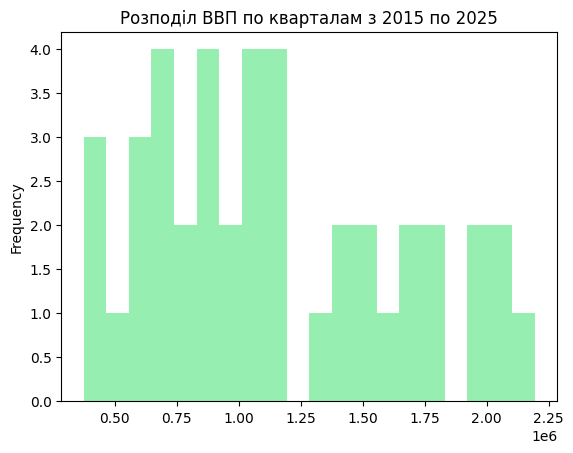

In [9]:
df_Ukraine_GDP_q['ВВП'].plot(kind='hist', bins=20, color='#7cea9c', alpha=0.8)
plt.title("Розподіл ВВП по кварталам з 2015 по 2025")
plt.show()

In [10]:
df_Ukraine_GDP_q['log_gdp'] = np.log(df_Ukraine_GDP_q['ВВП'])

In [11]:
df_Ukraine_GDP_q.head(5)

,ВВП України,ВВП,log_gdp
Показник,,,
2015-01-01,375991.0,375991.0,12.837320
2015-04-01,456715.0,456715.0,13.031815
2015-07-01,566997.0,566997.0,13.248109
2015-10-01,588841.0,588841.0,13.285911
2016-01-01,455298.0,455298.0,13.028707


In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

season_gdp = seasonal_decompose(df_Ukraine_GDP_q['log_gdp'], model='additive', period=4)
df_Ukraine_GDP_q['log_gdp_sa'] = df_Ukraine_GDP_q['log_gdp'] - season_gdp.seasonal 

In [13]:
df_Ukraine_GDP_q.head(5)

,ВВП України,ВВП,log_gdp,log_gdp_sa
Показник,,,,
2015-01-01,375991.0,375991.0,12.837320,12.983193
2015-04-01,456715.0,456715.0,13.031815,13.126004
2015-07-01,566997.0,566997.0,13.248109,13.145048
2015-10-01,588841.0,588841.0,13.285911,13.148911
2016-01-01,455298.0,455298.0,13.028707,13.174580


In [14]:
df_Ukraine_GDP_q['station_vrp'] = df_Ukraine_GDP_q['log_gdp_sa'].diff().dropna()

In [15]:
df_Ukraine_GDP_q.head(5)

,ВВП України,ВВП,log_gdp,log_gdp_sa,station_vrp
Показник,,,,,
2015-01-01,375991.0,375991.0,12.837320,12.983193,NaN
2015-04-01,456715.0,456715.0,13.031815,13.126004,0.142810
2015-07-01,566997.0,566997.0,13.248109,13.145048,0.019044
2015-10-01,588841.0,588841.0,13.285911,13.148911,0.003863
2016-01-01,455298.0,455298.0,13.028707,13.174580,0.025669


In [16]:
added_price = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому національні\\валова_додана_вартість.csv')
added_price

,Показник,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки часового ряду,Примітки спостереження,2015-Q1,2015-Q2,2015-Q3,...,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4
0,SSSU:DF_QUARTERLY_NATIONAL_ACCOUNTS(14.0.0),GROSS_VAL_ADDED.UA00000000000000000.CURR_PRICE...,Мільйони,Нуль,NaN,Дані наведено без урахування тимчасово окупова...,Дані попередні.,21029,18740,14392,...,38204,44989,51253,61077,59171,61965,44801,52024,59755,66749


In [17]:
added_price = added_price.iloc[:, -44:]
added_price

,2015-Q1,2015-Q2,2015-Q3,2015-Q4,2016-Q1,2016-Q2,2016-Q3,2016-Q4,2017-Q1,2017-Q2,...,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4
0,21029,18740,14392,13351,14755,16065,15935,18690,19240,20098,...,38204,44989,51253,61077,59171,61965,44801,52024,59755,66749


In [18]:
added_price = added_price.T
added_price

,0
2015-Q1,21029
2015-Q2,18740
2015-Q3,14392
2015-Q4,13351
2016-Q1,14755
2016-Q2,16065
2016-Q3,15935
2016-Q4,18690
2017-Q1,19240
2017-Q2,20098


In [19]:
added_price = added_price.reset_index()
added_price.columns = ['Показник', 'додана вартість']

In [20]:
added_price.head()

,Показник,додана вартість
0,2015-Q1,21029
1,2015-Q2,18740
2,2015-Q3,14392
3,2015-Q4,13351
4,2016-Q1,14755


In [21]:
added_price = added_price.copy()
added_price['Показник'] = added_price['Показник'].str.replace('-Q', 'Q')
added_price['Показник'] = pd.to_datetime(added_price['Показник'])
added_price.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_4340\203586600.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  added_price['Показник'] = pd.to_datetime(added_price['Показник'])


In [22]:
added_price.head()

,додана вартість
Показник,
2015-01-01,21029
2015-04-01,18740
2015-07-01,14392
2015-10-01,13351
2016-01-01,14755


In [23]:
main_data = df_Ukraine_GDP_q['ВВП України']

In [24]:
main_data = pd.merge(main_data, added_price, on='Показник', how='left')
main_data

,ВВП України,додана вартість
Показник,,
2015-01-01,375991.0,21029
2015-04-01,456715.0,18740
2015-07-01,566997.0,14392
2015-10-01,588841.0,13351
2016-01-01,455298.0,14755
2016-04-01,535701.0,16065
2016-07-01,671456.0,15935
2016-10-01,722912.0,18690
2017-01-01,591765.0,19240


In [25]:
export = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому\\export.csv')
export

,Показник,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки часового ряду,Примітки спостереження,2015-Q1,2015-Q2,2015-Q3,...,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4
0,SSSU:DF_QUARTERLY_NATIONAL_ACCOUNTS(14.0.0),EXPORTS_GOODS.UA00000000000000000.CURR_PRICES....,Мільйони,Нуль,NaN,Дані наведено без урахування тимчасово окупова...,Дані попередні.,249852,250632,266601,...,419478,481164,547562,556476,555756,613786,549603,556021,540931,616032


In [26]:
export = export.iloc[:, -44:]
export

,2015-Q1,2015-Q2,2015-Q3,2015-Q4,2016-Q1,2016-Q2,2016-Q3,2016-Q4,2017-Q1,2017-Q2,...,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4
0,249852,250632,266601,278843,252255,283545,299653,340500,343094,342075,...,419478,481164,547562,556476,555756,613786,549603,556021,540931,616032


In [27]:
export = export.T

In [28]:
export = export.reset_index()
export.columns = ['Показник', 'експорт']

In [29]:
export.head()

,Показник,експорт
0,2015-Q1,249852
1,2015-Q2,250632
2,2015-Q3,266601
3,2015-Q4,278843
4,2016-Q1,252255


In [30]:
export = export.copy()
export['Показник'] = export['Показник'].str.replace('-Q', 'Q')
export['Показник'] = pd.to_datetime(export['Показник'])
export.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_4340\1301554034.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  export['Показник'] = pd.to_datetime(export['Показник'])


In [31]:
main_data = pd.merge(main_data, export, on='Показник', how='left')
main_data

,ВВП України,додана вартість,експорт
Показник,,,
2015-01-01,375991.0,21029,249852
2015-04-01,456715.0,18740,250632
2015-07-01,566997.0,14392,266601
2015-10-01,588841.0,13351,278843
2016-01-01,455298.0,14755,252255
2016-04-01,535701.0,16065,283545
2016-07-01,671456.0,15935,299653
2016-10-01,722912.0,18690,340500
2017-01-01,591765.0,19240,343094


In [73]:
kyiv_gdp = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому\\Kyiv_gdp.csv')
kyiv_gdp

,Показник,Територіальний розріз,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки часового ряду,Примітки спостереження,2004,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,SSSU:DF_REGIONAL_ACCOUNTS(8.0.0),GRP.UA32000000000030281._Z.A,Річна,Гривня,Мільйони,Нуль,NaN,NaN,NaN,11883,...,69663,68931,79561,104030,128638,156829,198142,218647,242406,291519


In [74]:
kyiv_gdp = kyiv_gdp.iloc[:, -18:]
kyiv_gdp

,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,11883,15362,19188,26221,35687,37548,44953,59154,69663,68931,79561,104030,128638,156829,198142,218647,242406,291519


In [75]:
kyiv_gdp = kyiv_gdp.T
kyiv_gdp = kyiv_gdp.reset_index()
kyiv_gdp.columns = ['Показник', 'kyiv_gdp']

In [76]:
kyiv_gdp.head()

,Показник,kyiv_gdp
0,2004,11883
1,2005,15362
2,2006,19188
3,2007,26221
4,2008,35687


In [77]:
kyiv_gdp_q = kyiv_gdp.copy()
kyiv_gdp_q['Показник'] = pd.to_datetime(kyiv_gdp_q['Показник'].astype(str) + '-01-01')
kyiv_gdp_q = kyiv_gdp_q.set_index('Показник')

start_date = kyiv_gdp_q.index.min()
end_date = kyiv_gdp_q.index.max() + pd.offsets.YearEnd(0)

new_index = pd.date_range(start=start_date, end=end_date, freq='QS') # 'QE' для кінця кварталу

kyiv_gdp_q = kyiv_gdp_q.reindex(new_index)
kyiv_gdp_q


,kyiv_gdp
2004-01-01,11883.0
2004-04-01,NaN
2004-07-01,NaN
2004-10-01,NaN
2005-01-01,15362.0
...,...
2020-10-01,NaN
2021-01-01,291519.0
2021-04-01,NaN
2021-07-01,NaN


In [78]:
x_annual = np.arange(len(kyiv_gdp))
x_quarterly = np.linspace(0, len(kyiv_gdp) - 1, len(kyiv_gdp_q))
cs = CubicSpline(x_annual, kyiv_gdp['kyiv_gdp'])
kyiv_gdp_q['kyiv_gdp_inter'] = cs(x_quarterly) / 4  # Ділимо на 4, щоб наблизити до квартальних сум
kyiv_gdp_q

,kyiv_gdp,kyiv_gdp_inter
2004-01-01,11883.0,2970.750000
2004-04-01,NaN,3206.837453
2004-07-01,NaN,3418.737428
2004-10-01,NaN,3615.630190
2005-01-01,15362.0,3806.696007
...,...,...
2020-10-01,NaN,60962.925338
2021-01-01,291519.0,63239.843258
2021-04-01,NaN,65947.044563
2021-07-01,NaN,69141.392421


In [79]:
sums = kyiv_gdp_q.groupby(kyiv_gdp_q.index.year)['kyiv_gdp_inter'].transform('sum')
actual_annual = kyiv_gdp_q['kyiv_gdp'].ffill()

In [80]:
actual_annual, sums

(2004-01-01     11883.0
 2004-04-01     11883.0
 2004-07-01     11883.0
 2004-10-01     11883.0
 2005-01-01     15362.0
                 ...   
 2020-10-01    242406.0
 2021-01-01    291519.0
 2021-04-01    291519.0
 2021-07-01    291519.0
 2021-10-01    291519.0
 Freq: QS-JAN, Name: kyiv_gdp, Length: 72, dtype: float64,
 2004-01-01     13211.955071
 2004-04-01     13211.955071
 2004-07-01     13211.955071
 2004-10-01     13211.955071
 2005-01-01     16452.613474
                   ...      
 2020-10-01    233640.080137
 2021-01-01    271208.030242
 2021-04-01    271208.030242
 2021-07-01    271208.030242
 2021-10-01    271208.030242
 Freq: QS-JAN, Name: kyiv_gdp_inter, Length: 72, dtype: float64)

In [81]:
kyiv_gdp_q['kyiv_gdp_inter'] = kyiv_gdp_q['kyiv_gdp_inter'] * (actual_annual / sums)

print(kyiv_gdp_q[['kyiv_gdp_inter']])

            kyiv_gdp_inter
2004-01-01     2671.930238
2004-04-01     2884.270288
2004-07-01     3074.855813
2004-10-01     3251.943661
2005-01-01     3554.357133
...                    ...
2020-10-01    63250.187514
2021-01-01    67975.921843
2021-04-01    70885.867453
2021-07-01    74319.442382
2021-10-01    78337.768322

[72 rows x 1 columns]


In [82]:
kyiv_gdp_q.head()

,kyiv_gdp,kyiv_gdp_inter
2004-01-01,11883.0,2671.930238
2004-04-01,NaN,2884.270288
2004-07-01,NaN,3074.855813
2004-10-01,NaN,3251.943661
2005-01-01,15362.0,3554.357133


In [83]:
kyiv_gdp_q = kyiv_gdp_q[['kyiv_gdp_inter']]

In [84]:
kyiv_gdp_q = kyiv_gdp_q.reset_index()
kyiv_gdp_q.columns = ['Показник', 'kyiv_gdp']

In [86]:
kyiv_gdp_q.head()

,Показник,kyiv_gdp
0,2004-01-01,2671.930238
1,2004-04-01,2884.270288
2,2004-07-01,3074.855813
3,2004-10-01,3251.943661
4,2005-01-01,3554.357133


In [87]:
main_data = pd.merge(main_data, kyiv_gdp_q, on='Показник', how='left')
main_data

,Показник,ВВП України,додана вартість,експорт,kyiv_gdp
0,2015-01-01,375991.0,21029,249852,23600.944176
1,2015-04-01,456715.0,18740,250632,25205.627447
2,2015-07-01,566997.0,14392,266601,26824.262110
3,2015-10-01,588841.0,13351,278843,28399.166267
4,2016-01-01,455298.0,14755,252255,29944.363432
5,2016-04-01,535701.0,16065,283545,31436.535359
6,2016-07-01,671456.0,15935,299653,32900.413467
7,2016-10-01,722912.0,18690,340500,34356.687743
8,2017-01-01,591765.0,19240,343094,36262.542363
9,2017-04-01,664307.0,20098,342075,38007.226259


In [94]:
added_prices_kyiv = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому\\added_price_kyiv.csv')
added_prices_kyiv

,Показник,Територіальний розріз,Вид економічної діяльності,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки часового ряду,Примітки спостереження,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,SSSU:DF_REGIONAL_ACCOUNTS(8.0.0),GVA.UA32000000000030281.K.A,Фінансова та страхова діяльність,Річна,Гривня,Мільйони,Нуль,NaN,NaN,NaN,927,870,938,1125,1398,1756,2102,2716,3753,4326


In [95]:
added_prices_kyiv = added_prices_kyiv.iloc[:, -10:]
added_prices_kyiv

,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,927,870,938,1125,1398,1756,2102,2716,3753,4326


In [96]:
added_prices_kyiv = added_prices_kyiv.T
added_prices_kyiv = added_prices_kyiv.reset_index()
added_prices_kyiv.columns = ['Показник', 'kyiv_added_price']

In [97]:
added_prices_kyiv.head()

,Показник,kyiv_added_price
0,2012,927
1,2013,870
2,2014,938
3,2015,1125
4,2016,1398


In [98]:
added_prices_kyiv_q = added_prices_kyiv.copy()
added_prices_kyiv_q['Показник'] = pd.to_datetime(added_prices_kyiv_q['Показник'].astype(str) + '-01-01')
added_prices_kyiv_q = added_prices_kyiv_q.set_index('Показник')

start_date = added_prices_kyiv_q.index.min()
end_date = added_prices_kyiv_q.index.max() + pd.offsets.YearEnd(0)

new_index = pd.date_range(start=start_date, end=end_date, freq='QS') # 'QE' для кінця кварталу

added_prices_kyiv_q = added_prices_kyiv_q.reindex(new_index)
added_prices_kyiv_q

,kyiv_added_price
2012-01-01,927.0
2012-04-01,NaN
2012-07-01,NaN
2012-10-01,NaN
2013-01-01,870.0
2013-04-01,NaN
2013-07-01,NaN
2013-10-01,NaN
2014-01-01,938.0
2014-04-01,NaN


In [99]:
x_annual = np.arange(len(added_prices_kyiv))
x_quarterly = np.linspace(0, len(added_prices_kyiv) - 1, len(added_prices_kyiv_q))
cs = CubicSpline(x_annual, added_prices_kyiv['kyiv_added_price'])
added_prices_kyiv_q['kyiv_added_price_inter'] = cs(x_quarterly) / 4  # Ділимо на 4, щоб наблизити до квартальних сум
added_prices_kyiv_q.head()

,kyiv_added_price,kyiv_added_price_inter
2012-01-01,927.0,231.750000
2012-04-01,NaN,225.781243
2012-07-01,NaN,221.403613
2012-10-01,NaN,218.639031
2013-01-01,870.0,217.509421


In [101]:
sums = added_prices_kyiv_q.groupby(added_prices_kyiv_q.index.year)['kyiv_added_price_inter'].transform('sum')
actual_annual = added_prices_kyiv_q['kyiv_added_price'].ffill()

In [102]:
added_prices_kyiv_q['kyiv_added_price_inter'] = added_prices_kyiv_q['kyiv_added_price_inter'] * (actual_annual / sums)

print(added_prices_kyiv_q[['kyiv_added_price_inter']])

            kyiv_added_price_inter
2012-01-01              239.347705
2012-04-01              233.183268
2012-07-01              228.662121
2012-10-01              225.806905
2013-01-01              215.052735
2013-04-01              215.574063
2013-07-01              217.755245
2013-10-01              221.617957
2014-01-01              222.235645
2014-04-01              229.366196
2014-07-01              238.115631
2014-10-01              248.282527
2015-01-01              261.659539
2015-04-01              274.117887
2015-07-01              287.437229
2015-10-01              301.785345
2016-01-01              321.801694
2016-04-01              339.177466
2016-07-01              358.287892
2016-10-01              378.732948
2017-01-01              408.262672
2017-04-01              429.459359
2017-07-01              449.613707
2017-10-01              468.664262
2018-01-01              492.309000
2018-04-01              512.671585
2018-07-01              535.378781
2018-10-01          

In [103]:
added_prices_kyiv_q = added_prices_kyiv_q[['kyiv_added_price_inter']]

In [104]:
added_prices_kyiv_q = added_prices_kyiv_q.reset_index()
added_prices_kyiv_q.columns = ['Показник', 'kyiv_added_price']

In [105]:
main_data = pd.merge(main_data, added_prices_kyiv_q, on='Показник', how='left')
main_data

,Показник,ВВП України,додана вартість,експорт,kyiv_gdp,kyiv_added_price
0,2015-01-01,375991.0,21029,249852,23600.944176,261.659539
1,2015-04-01,456715.0,18740,250632,25205.627447,274.117887
2,2015-07-01,566997.0,14392,266601,26824.262110,287.437229
3,2015-10-01,588841.0,13351,278843,28399.166267,301.785345
4,2016-01-01,455298.0,14755,252255,29944.363432,321.801694
5,2016-04-01,535701.0,16065,283545,31436.535359,339.177466
6,2016-07-01,671456.0,15935,299653,32900.413467,358.287892
7,2016-10-01,722912.0,18690,340500,34356.687743,378.732948
8,2017-01-01,591765.0,19240,343094,36262.542363,408.262672
9,2017-04-01,664307.0,20098,342075,38007.226259,429.459359


In [106]:
ind_house_prices = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому\\index_house_prices.csv')
ind_house_prices

,Показник,Базисний період,Територіальний розріз,Інші розрізи,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки часового ряду,...,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4
0,SSSU:DF_PRICE_CHANGE_HOUSING_MARKET(15.0.0),INDEX_HOUSPRICE.PREV_QUART.UA00000000000000000...,Україна,Квартири двокімнатні на первинному ринку,Квартальна,Відсоток,Одиниці,Один,NaN,1. Дані за 2016-2021 роки наводяться без ураху...,...,104.9,102.1,105.3,102.2,103.9,104,104.2,103.6,100,104.2


In [107]:
ind_house_prices = ind_house_prices.iloc[:, -40:]
ind_house_prices

,2016-Q1,2016-Q2,2016-Q3,2016-Q4,2017-Q1,2017-Q2,2017-Q3,2017-Q4,2018-Q1,2018-Q2,...,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4
0,100.9,98,101.1,105.2,101,100.6,100.4,101.4,102.2,101.1,...,104.9,102.1,105.3,102.2,103.9,104,104.2,103.6,100,104.2


In [108]:
ind_house_prices = ind_house_prices.T
ind_house_prices = ind_house_prices.reset_index()
ind_house_prices.columns = ['Показник', 'ukr_index_house_prices']

In [109]:
ind_house_prices = ind_house_prices.copy()
ind_house_prices['Показник'] = ind_house_prices['Показник'].str.replace('-Q', 'Q')
ind_house_prices['Показник'] = pd.to_datetime(ind_house_prices['Показник'])
ind_house_prices.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_4340\2649527543.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ind_house_prices['Показник'] = pd.to_datetime(ind_house_prices['Показник'])


In [110]:
main_data = pd.merge(main_data, ind_house_prices, on='Показник', how='left')
main_data

,Показник,ВВП України,додана вартість,експорт,kyiv_gdp,kyiv_added_price,ukr_index_house_prices
0,2015-01-01,375991.0,21029,249852,23600.944176,261.659539,NaN
1,2015-04-01,456715.0,18740,250632,25205.627447,274.117887,NaN
2,2015-07-01,566997.0,14392,266601,26824.262110,287.437229,NaN
3,2015-10-01,588841.0,13351,278843,28399.166267,301.785345,NaN
4,2016-01-01,455298.0,14755,252255,29944.363432,321.801694,100.9
5,2016-04-01,535701.0,16065,283545,31436.535359,339.177466,98.0
6,2016-07-01,671456.0,15935,299653,32900.413467,358.287892,101.1
7,2016-10-01,722912.0,18690,340500,34356.687743,378.732948,105.2
8,2017-01-01,591765.0,19240,343094,36262.542363,408.262672,101.0
9,2017-04-01,664307.0,20098,342075,38007.226259,429.459359,100.6


In [111]:
empl_kyiv = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому\\empl_kyiv.csv')
empl_kyiv = empl_kyiv.head(1)
empl_kyiv

,Показник,Територіальний розріз,Вікова група,Одиниця виміру,Періодичність,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки часового ряду,Примітки спостереження,...,2019-Q3,2019-Q4,2020-Q1,2020-Q2,2020-Q3,2020-Q4,2021-Q1,2021-Q2,2021-Q3,2021-Q4
0,SSSU:DF_LABOR_FORCE_Q(2.0.1),EMPL_POPUL_PERS_CUM.UA32000000000030281._T._T....,Працездатний вік,Особа,Квартальна,Тисячі,Один,NaN,NaN,Дані наведено за січень-грудень.,...,757.7,754.8,758.4,744.2,742.9,738.8,716.7,724.4,731.4,727.2


In [112]:
empl_kyiv = empl_kyiv.iloc[:, -28:]
empl_kyiv

,2015-Q1,2015-Q2,2015-Q3,2015-Q4,2016-Q1,2016-Q2,2016-Q3,2016-Q4,2017-Q1,2017-Q2,...,2019-Q3,2019-Q4,2020-Q1,2020-Q2,2020-Q3,2020-Q4,2021-Q1,2021-Q2,2021-Q3,2021-Q4
0,723.2,722.5,727.1,726.9,729.3,728.8,724.5,722.6,729.9,732.8,...,757.7,754.8,758.4,744.2,742.9,738.8,716.7,724.4,731.4,727.2


In [113]:
empl_kyiv = empl_kyiv.T
empl_kyiv = empl_kyiv.reset_index()
empl_kyiv.columns = ['Показник', 'empl_kyiv']

In [114]:
empl_kyiv = empl_kyiv.copy()
empl_kyiv['Показник'] = empl_kyiv['Показник'].str.replace('-Q', 'Q')
empl_kyiv['Показник'] = pd.to_datetime(empl_kyiv['Показник'])
empl_kyiv.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_4340\1146612851.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  empl_kyiv['Показник'] = pd.to_datetime(empl_kyiv['Показник'])


In [115]:
main_data = pd.merge(main_data, empl_kyiv, on='Показник', how='left')
main_data

,Показник,ВВП України,додана вартість,експорт,kyiv_gdp,kyiv_added_price,ukr_index_house_prices,empl_kyiv
0,2015-01-01,375991.0,21029,249852,23600.944176,261.659539,NaN,723.2
1,2015-04-01,456715.0,18740,250632,25205.627447,274.117887,NaN,722.5
2,2015-07-01,566997.0,14392,266601,26824.262110,287.437229,NaN,727.1
3,2015-10-01,588841.0,13351,278843,28399.166267,301.785345,NaN,726.9
4,2016-01-01,455298.0,14755,252255,29944.363432,321.801694,100.9,729.3
5,2016-04-01,535701.0,16065,283545,31436.535359,339.177466,98.0,728.8
6,2016-07-01,671456.0,15935,299653,32900.413467,358.287892,101.1,724.5
7,2016-10-01,722912.0,18690,340500,34356.687743,378.732948,105.2,722.6
8,2017-01-01,591765.0,19240,343094,36262.542363,408.262672,101.0,729.9
9,2017-04-01,664307.0,20098,342075,38007.226259,429.459359,100.6,732.8


In [116]:
infl_ukr = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому\\infl_ukr.csv')
infl_ukr

,Показник,Базисний період,Територіальний розріз,Тип товарів і послуг,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки часового ряду,...,2025-M05,2025-M06,2025-M07,2025-M08,2025-M09,2025-M10,2025-M11,2025-M12,2026-M01,2026-M02
0,SSSU:DF_PRICE_CHANGE_CONSUMER_GOODS_SERVICE(27...,INDEX_CONSUMPRICE.PREV_MONTH.UA000000000000000...,Україна,Індекс споживчих цін,Місячна,Відсоток,Одиниці,Один,NaN,1. З 1991 року. 2. Індекси споживчих цін до ві...,...,101.3,100.8,99.8,99.8,100.3,100.9,100.4,100.2,100.7,101


In [117]:
infl_ukr = infl_ukr.iloc[:, -420:]
infl_ukr

,1991-M03,1991-M04,1991-M05,1991-M06,1991-M07,1991-M08,1991-M09,1991-M10,1991-M11,1991-M12,...,2025-M05,2025-M06,2025-M07,2025-M08,2025-M09,2025-M10,2025-M11,2025-M12,2026-M01,2026-M02
0,NaN,NaN,NaN,NaN,NaN,104,104.5,105.9,116.5,124.6,...,101.3,100.8,99.8,99.8,100.3,100.9,100.4,100.2,100.7,101


In [118]:
infl_ukr = infl_ukr.T
infl_ukr = infl_ukr.reset_index()
infl_ukr.columns = ['Показник', 'infl_ukr']

In [119]:
infl_ukr.tail()

,Показник,infl_ukr
415,2025-M10,100.9
416,2025-M11,100.4
417,2025-M12,100.2
418,2026-M01,100.7
419,2026-M02,101.0


In [120]:
infl_ukr['Показник'] = infl_ukr['Показник'].str.replace('-M', '-', regex=False)
infl_ukr['Показник'] = pd.to_datetime(infl_ukr['Показник'])
infl_ukr = infl_ukr.set_index('Показник')

In [121]:
infl_ukr = infl_ukr['infl_ukr'].resample('Q').mean()
infl_ukr = infl_ukr.reset_index()
print(infl_ukr)

      Показник    infl_ukr
0   1991-03-31         NaN
1   1991-06-30         NaN
2   1991-09-30  104.250000
3   1991-12-31  115.666667
4   1992-03-31  204.200000
..         ...         ...
136 2025-03-31  101.166667
137 2025-06-30  100.933333
138 2025-09-30   99.966667
139 2025-12-31  100.500000
140 2026-03-31  100.850000

[141 rows x 2 columns]


In [122]:
# Для інфляції (infl_ukr)
infl_ukr['Показник'] = pd.to_datetime(infl_ukr['Показник']).dt.to_period('Q')

# Для ВВП (припустимо, він називається gdp_df)
main_data['Показник'] = pd.to_datetime(main_data['Показник']).dt.to_period('Q')

In [123]:
main_data = pd.merge(main_data, infl_ukr, on='Показник', how='left')
main_data

,Показник,ВВП України,додана вартість,експорт,kyiv_gdp,kyiv_added_price,ukr_index_house_prices,empl_kyiv,infl_ukr
0,2015Q1,375991.0,21029,249852,23600.944176,261.659539,NaN,723.2,106.400000
1,2015Q2,456715.0,18740,250632,25205.627447,274.117887,NaN,722.5,105.533333
2,2015Q3,566997.0,14392,266601,26824.262110,287.437229,NaN,727.1,100.166667
3,2015Q4,588841.0,13351,278843,28399.166267,301.785345,NaN,726.9,100.466667
4,2016Q1,455298.0,14755,252255,29944.363432,321.801694,100.9,729.3,100.500000
5,2016Q2,535701.0,16065,283545,31436.535359,339.177466,98.0,728.8,101.133333
6,2016Q3,671456.0,15935,299653,32900.413467,358.287892,101.1,724.5,100.466667
7,2016Q4,722912.0,18690,340500,34356.687743,378.732948,105.2,722.6,101.833333
8,2017Q1,591765.0,19240,343094,36262.542363,408.262672,101.0,729.9,101.300000
9,2017Q2,664307.0,20098,342075,38007.226259,429.459359,100.6,732.8,101.266667


In [124]:
unemp_kyiv = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому\\unemp_kyiv.csv')
unemp_kyiv

,Показник,Територіальний розріз,Вікова група,Одиниця виміру,Періодичність,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки часового ряду,Примітки спостереження,...,2019-Q3,2019-Q4,2020-Q1,2020-Q2,2020-Q3,2020-Q4,2021-Q1,2021-Q2,2021-Q3,2021-Q4
0,SSSU:DF_LABOR_FORCE_Q(2.0.1),UNEMPL_POPUL_PERS_CUM.UA32000000000030281._T._...,Працездатний вік,Особа,Квартальна,Тисячі,Один,NaN,Відсотків до робочої сили.,Дані наведено за січень-грудень.,...,47.1,48.3,49.1,53.9,55.1,55.8,61.4,56.8,55.7,57.3


In [125]:
unemp_kyiv = unemp_kyiv.iloc[:, -28:]
unemp_kyiv

,2015-Q1,2015-Q2,2015-Q3,2015-Q4,2016-Q1,2016-Q2,2016-Q3,2016-Q4,2017-Q1,2017-Q2,...,2019-Q3,2019-Q4,2020-Q1,2020-Q2,2020-Q3,2020-Q4,2021-Q1,2021-Q2,2021-Q3,2021-Q4
0,61.1,53.6,50.2,50.7,57.3,52.4,52.9,53.5,54.1,51,...,47.1,48.3,49.1,53.9,55.1,55.8,61.4,56.8,55.7,57.3


In [126]:
unemp_kyiv = unemp_kyiv.T
unemp_kyiv = unemp_kyiv.reset_index()
unemp_kyiv.columns = ['Показник', 'unempl_kyiv']

In [127]:
unemp_kyiv = unemp_kyiv.copy()
unemp_kyiv['Показник'] = unemp_kyiv['Показник'].str.replace('-Q', 'Q')
unemp_kyiv['Показник'] = pd.to_datetime(unemp_kyiv['Показник']).dt.to_period('Q')
unemp_kyiv.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_4340\1183706190.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  unemp_kyiv['Показник'] = pd.to_datetime(unemp_kyiv['Показник']).dt.to_period('Q')


In [128]:
main_data = pd.merge(main_data, unemp_kyiv, on='Показник', how='left')
main_data

,Показник,ВВП України,додана вартість,експорт,kyiv_gdp,kyiv_added_price,ukr_index_house_prices,empl_kyiv,infl_ukr,unempl_kyiv
0,2015Q1,375991.0,21029,249852,23600.944176,261.659539,NaN,723.2,106.400000,61.1
1,2015Q2,456715.0,18740,250632,25205.627447,274.117887,NaN,722.5,105.533333,53.6
2,2015Q3,566997.0,14392,266601,26824.262110,287.437229,NaN,727.1,100.166667,50.2
3,2015Q4,588841.0,13351,278843,28399.166267,301.785345,NaN,726.9,100.466667,50.7
4,2016Q1,455298.0,14755,252255,29944.363432,321.801694,100.9,729.3,100.500000,57.3
5,2016Q2,535701.0,16065,283545,31436.535359,339.177466,98.0,728.8,101.133333,52.4
6,2016Q3,671456.0,15935,299653,32900.413467,358.287892,101.1,724.5,100.466667,52.9
7,2016Q4,722912.0,18690,340500,34356.687743,378.732948,105.2,722.6,101.833333,53.5
8,2017Q1,591765.0,19240,343094,36262.542363,408.262672,101.0,729.9,101.300000,54.1
9,2017Q2,664307.0,20098,342075,38007.226259,429.459359,100.6,732.8,101.266667,51.0


In [129]:
constr_ind = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому\\constr_ind.csv')
constr_ind

,Тенденції ділової активності,Показник,Територіальний розріз,Тренд,Вид економічної діяльності,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,...,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4,2026-Q1
0,SSSU:DF_BUSINESS_ACTIVITY_STATE_ENTERPRISE(19....,IND_BUS_EXPECT.INDCTR_CONSTR_CONF.UA0000000000...,Україна,Індикатор,Будівництво,Квартальна,Відсоток,Одиниці,Один,NaN,...,-42.8,-40.5,-41.3,-46.4,-40.8,-38.7,-34.9,-32.2,-28.9,-27.7


In [130]:
constr_ind = constr_ind.iloc[:, -45:]
constr_ind

,2015-Q1,2015-Q2,2015-Q3,2015-Q4,2016-Q1,2016-Q2,2016-Q3,2016-Q4,2017-Q1,2017-Q2,...,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4,2026-Q1
0,-44,-46.9,-44.8,-38,-34.8,-29.9,-30.7,-29.2,-28.8,-24,...,-42.8,-40.5,-41.3,-46.4,-40.8,-38.7,-34.9,-32.2,-28.9,-27.7


In [131]:
constr_ind = constr_ind.T
constr_ind = constr_ind.reset_index()
constr_ind.columns = ['Показник', 'constr_ind']

In [132]:
constr_ind = constr_ind.copy()
constr_ind['Показник'] = constr_ind['Показник'].str.replace('-Q', 'Q')
constr_ind['Показник'] = pd.to_datetime(constr_ind['Показник']).dt.to_period('Q')
constr_ind.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_4340\3610339610.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  constr_ind['Показник'] = pd.to_datetime(constr_ind['Показник']).dt.to_period('Q')


In [133]:
main_data = pd.merge(main_data, constr_ind, on='Показник', how='left')
main_data.head()

,Показник,ВВП України,додана вартість,експорт,kyiv_gdp,kyiv_added_price,ukr_index_house_prices,empl_kyiv,infl_ukr,unempl_kyiv,constr_ind
0,2015Q1,375991.0,21029,249852,23600.944176,261.659539,NaN,723.2,106.400000,61.1,-44.0
1,2015Q2,456715.0,18740,250632,25205.627447,274.117887,NaN,722.5,105.533333,53.6,-46.9
2,2015Q3,566997.0,14392,266601,26824.262110,287.437229,NaN,727.1,100.166667,50.2,-44.8
3,2015Q4,588841.0,13351,278843,28399.166267,301.785345,NaN,726.9,100.466667,50.7,-38.0
4,2016Q1,455298.0,14755,252255,29944.363432,321.801694,100.9,729.3,100.500000,57.3,-34.8


In [134]:
finance_ind = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому\\finance_ind.csv')
finance_ind

,Тенденції ділової активності,Показник,Територіальний розріз,Тренд,Вид економічної діяльності,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,...,2022-Q3,2022-Q4,2023-Q1,2023-Q2,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4
0,SSSU:DF_BUSINESS_ACTIVITY_STATE_ENTERPRISE(19....,IND_BUS_EXPECT.INDCTR_FIN_SERVICE_MANUF.UA0000...,Україна,Індикатор,Фінансова та страхова діяльність,Квартальна,Відсоток,Одиниці,Один,NaN,...,-57,-28.7,-16.7,-8,-3.3,6.3,-3.3,-4.7,-5.3,-4


In [135]:
finance_ind = finance_ind.iloc[:, -40:]
finance_ind

,2015-Q1,2015-Q2,2015-Q3,2015-Q4,2016-Q1,2016-Q2,2016-Q3,2016-Q4,2017-Q1,2017-Q2,...,2022-Q3,2022-Q4,2023-Q1,2023-Q2,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4
0,-45,-35.3,-32.7,-27,-24.7,-17,-13,-12.3,-16.3,-12.7,...,-57,-28.7,-16.7,-8,-3.3,6.3,-3.3,-4.7,-5.3,-4


In [136]:
finance_ind = finance_ind.T
finance_ind = finance_ind.reset_index()
finance_ind.columns = ['Показник', 'finance_ind']

In [137]:
finance_ind = finance_ind.copy()
finance_ind['Показник'] = finance_ind['Показник'].str.replace('-Q', 'Q')
finance_ind['Показник'] = pd.to_datetime(finance_ind['Показник']).dt.to_period('Q')
finance_ind.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_4340\2707840936.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  finance_ind['Показник'] = pd.to_datetime(finance_ind['Показник']).dt.to_period('Q')


In [138]:
main_data = pd.merge(main_data, finance_ind, on='Показник', how='left')
main_data.head()

,Показник,ВВП України,додана вартість,експорт,kyiv_gdp,kyiv_added_price,ukr_index_house_prices,empl_kyiv,infl_ukr,unempl_kyiv,constr_ind,finance_ind
0,2015Q1,375991.0,21029,249852,23600.944176,261.659539,NaN,723.2,106.400000,61.1,-44.0,-45.0
1,2015Q2,456715.0,18740,250632,25205.627447,274.117887,NaN,722.5,105.533333,53.6,-46.9,-35.3
2,2015Q3,566997.0,14392,266601,26824.262110,287.437229,NaN,727.1,100.166667,50.2,-44.8,-32.7
3,2015Q4,588841.0,13351,278843,28399.166267,301.785345,NaN,726.9,100.466667,50.7,-38.0,-27.0
4,2016Q1,455298.0,14755,252255,29944.363432,321.801694,100.9,729.3,100.500000,57.3,-34.8,-24.7


In [139]:
import_ua = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому\\import.csv')
import_ua

,Показник,Територіальний розріз,Вид ціни,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки часового ряду,Примітки спостереження,...,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4
0,SSSU:DF_QUARTERLY_NATIONAL_ACCOUNTS(14.0.0),IMPORTS_GOODS.UA00000000000000000.CURR_PRICES....,У фактичних цінах,Квартальна,Гривня,Мільйони,Нуль,NaN,Дані наведено без урахування тимчасово окупова...,Дані попередні.,...,806630,845914,830886,931939,992589,1077036,1025075,1103501,1169841,1332116


In [140]:
import_ua = import_ua.iloc[:, -44:]
import_ua

,2015-Q1,2015-Q2,2015-Q3,2015-Q4,2016-Q1,2016-Q2,2016-Q3,2016-Q4,2017-Q1,2017-Q2,...,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4
0,263833,255842,279179,299000,297742,297743,357989,387641,380437,388803,...,806630,845914,830886,931939,992589,1077036,1025075,1103501,1169841,1332116


In [141]:
import_ua = import_ua.T
import_ua = import_ua.reset_index()
import_ua.columns = ['Показник', 'import_ua']

In [142]:
import_ua = import_ua.copy()
import_ua['Показник'] = import_ua['Показник'].str.replace('-Q', 'Q')
import_ua['Показник'] = pd.to_datetime(import_ua['Показник']).dt.to_period('Q')
import_ua.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_4340\1011053231.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  import_ua['Показник'] = pd.to_datetime(import_ua['Показник']).dt.to_period('Q')


In [143]:
main_data = pd.merge(main_data, import_ua, on='Показник', how='left')
main_data.head()

,Показник,ВВП України,додана вартість,експорт,kyiv_gdp,kyiv_added_price,ukr_index_house_prices,empl_kyiv,infl_ukr,unempl_kyiv,constr_ind,finance_ind,import_ua
0,2015Q1,375991.0,21029,249852,23600.944176,261.659539,NaN,723.2,106.400000,61.1,-44.0,-45.0,263833
1,2015Q2,456715.0,18740,250632,25205.627447,274.117887,NaN,722.5,105.533333,53.6,-46.9,-35.3,255842
2,2015Q3,566997.0,14392,266601,26824.262110,287.437229,NaN,727.1,100.166667,50.2,-44.8,-32.7,279179
3,2015Q4,588841.0,13351,278843,28399.166267,301.785345,NaN,726.9,100.466667,50.7,-38.0,-27.0,299000
4,2016Q1,455298.0,14755,252255,29944.363432,321.801694,100.9,729.3,100.500000,57.3,-34.8,-24.7,297742


In [144]:
sal_ind_kyiv = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому\\salaries_ind_kyiv.csv')
sal_ind_kyiv

,Показник,Територіальний розріз,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки часового ряду,Примітки спостереження,2002,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,SSSU:DF_REGIONAL_ACCOUNTS(8.0.0),CHNF_SAL_VOL.UA32000000000030281._Z.A,Річна,Відсоток,Одиниці,Один,NaN,NaN,NaN,116.8,...,116.2,104.3,106.6,119.5,131.5,135.5,131.1,115.7,104.4,120.2


In [145]:
sal_ind_kyiv = sal_ind_kyiv.iloc[:, -20:]
sal_ind_kyiv

,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,116.8,120.5,125.5,138,129.5,136.1,132.3,99.1,123.4,120.7,116.2,104.3,106.6,119.5,131.5,135.5,131.1,115.7,104.4,120.2


In [146]:
sal_ind_kyiv = sal_ind_kyiv.T
sal_ind_kyiv = sal_ind_kyiv.reset_index()
sal_ind_kyiv.columns = ['Показник', 'salaries_ind_kyiv']

In [147]:
sal_ind_kyiv = sal_ind_kyiv.copy()
sal_ind_kyiv['Показник'] = pd.to_datetime(sal_ind_kyiv['Показник'].astype(str) + '-01-01')
sal_ind_kyiv.set_index('Показник', inplace=True)


In [148]:
quarterly_index = pd.date_range(start=sal_ind_kyiv.index.min(), end=sal_ind_kyiv.index.max(), freq='QS')

sal_ind_kyiv = sal_ind_kyiv.reindex(quarterly_index)

In [149]:
sal_ind_kyiv['salaries_ind_kyiv'] = sal_ind_kyiv['salaries_ind_kyiv'].interpolate(method='cubicspline')

In [150]:
sal_ind_kyiv = sal_ind_kyiv.reset_index()
sal_ind_kyiv.columns = ['Показник', 'salaries_ind_kyiv']

In [151]:
sal_ind_kyiv['Показник'] = pd.to_datetime(sal_ind_kyiv['Показник']).dt.to_period('Q')

In [152]:
sal_ind_kyiv.head()

,Показник,salaries_ind_kyiv
0,2002Q1,116.800000
1,2002Q2,118.734483
2,2002Q3,119.791549
3,2002Q4,120.273034
4,2003Q1,120.500000


In [153]:
main_data = pd.merge(main_data, sal_ind_kyiv, on='Показник', how='left')
main_data.head()

,Показник,ВВП України,додана вартість,експорт,kyiv_gdp,kyiv_added_price,ukr_index_house_prices,empl_kyiv,infl_ukr,unempl_kyiv,constr_ind,finance_ind,import_ua,salaries_ind_kyiv
0,2015Q1,375991.0,21029,249852,23600.944176,261.659539,NaN,723.2,106.400000,61.1,-44.0,-45.0,263833,119.500000
1,2015Q2,456715.0,18740,250632,25205.627447,274.117887,NaN,722.5,105.533333,53.6,-46.9,-35.3,255842,122.923680
2,2015Q3,566997.0,14392,266601,26824.262110,287.437229,NaN,727.1,100.166667,50.2,-44.8,-32.7,279179,126.167396
3,2015Q4,588841.0,13351,278843,28399.166267,301.785345,NaN,726.9,100.466667,50.7,-38.0,-27.0,299000,129.085457
4,2016Q1,455298.0,14755,252255,29944.363432,321.801694,100.9,729.3,100.500000,57.3,-34.8,-24.7,297742,131.500000


In [154]:
service_ind = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому\\service_ind.csv')
service_ind

,Тенденції ділової активності,Показник,Територіальний розріз,Тренд,Вид економічної діяльності,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,...,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4,2026-Q1
0,SSSU:DF_BUSINESS_ACTIVITY_STATE_ENTERPRISE(19....,IND_BUS_EXPECT.INDCTR_SERVICE_CONF.UA000000000...,Україна,Індикатор,Сфера послуг,Квартальна,Відсоток,Одиниці,Один,NaN,...,-5.5,-7.8,-7.4,-8,-7.7,-6.4,-7,-3.6,-5.1,-4.4


In [155]:
service_ind = service_ind.iloc[:, -45:]
service_ind

,2015-Q1,2015-Q2,2015-Q3,2015-Q4,2016-Q1,2016-Q2,2016-Q3,2016-Q4,2017-Q1,2017-Q2,...,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4,2026-Q1
0,-33,-29.1,-25.7,-19.7,-17.7,-14.3,-11,-10.1,-11.6,-7.4,...,-5.5,-7.8,-7.4,-8,-7.7,-6.4,-7,-3.6,-5.1,-4.4


In [156]:
service_ind = service_ind.T
service_ind = service_ind.reset_index()
service_ind.columns = ['Показник', 'service_ind']

In [157]:
service_ind = service_ind.copy()
service_ind['Показник'] = service_ind['Показник'].str.replace('-Q', 'Q')
service_ind['Показник'] = pd.to_datetime(service_ind['Показник']).dt.to_period('Q')
service_ind.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_4340\1597319522.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  service_ind['Показник'] = pd.to_datetime(service_ind['Показник']).dt.to_period('Q')


In [158]:
main_data = pd.merge(main_data, service_ind, on='Показник', how='left')
main_data.head()

,Показник,ВВП України,додана вартість,експорт,kyiv_gdp,kyiv_added_price,ukr_index_house_prices,empl_kyiv,infl_ukr,unempl_kyiv,constr_ind,finance_ind,import_ua,salaries_ind_kyiv,service_ind
0,2015Q1,375991.0,21029,249852,23600.944176,261.659539,NaN,723.2,106.400000,61.1,-44.0,-45.0,263833,119.500000,-33.0
1,2015Q2,456715.0,18740,250632,25205.627447,274.117887,NaN,722.5,105.533333,53.6,-46.9,-35.3,255842,122.923680,-29.1
2,2015Q3,566997.0,14392,266601,26824.262110,287.437229,NaN,727.1,100.166667,50.2,-44.8,-32.7,279179,126.167396,-25.7
3,2015Q4,588841.0,13351,278843,28399.166267,301.785345,NaN,726.9,100.466667,50.7,-38.0,-27.0,299000,129.085457,-19.7
4,2016Q1,455298.0,14755,252255,29944.363432,321.801694,100.9,729.3,100.500000,57.3,-34.8,-24.7,297742,131.500000,-17.7


In [159]:
house_space = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому\\house_space.csv')
house_space

,Показник,Територіальний розріз,Тип будівлі,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,Примітки часового ряду,Примітки спостереження,...,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4
0,SSSU:DF_BEGINING_COMPLETION_CONSTRUCTION(25.0.0),AREA_LIV_DWELLINGS_RESIDEN_BUILD.UA00000000000...,Житлові будинки без житлових будинків для коле...,Квартальна,Квадратний метр,Одиниці,Нуль,Конфіденційна статистична інформація,1. Дані наведено без урахування тимчасово окуп...,NaN,...,NaN,3389532,NaN,NaN,3111724,4518426,1036502,1937425,2944300,4295907


In [160]:
house_space = house_space.iloc[:, -32:]
house_space

,2018-Q1,2018-Q2,2018-Q3,2018-Q4,2019-Q1,2019-Q2,2019-Q3,2019-Q4,2020-Q1,2020-Q2,...,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4
0,876116,1523985,2436786,4062604,1135242,2293419,3598743,5127357,887514,1715138,...,NaN,3389532,NaN,NaN,3111724,4518426,1036502,1937425,2944300,4295907


In [161]:
house_space = house_space.T
house_space = house_space.reset_index()
house_space.columns = ['Показник', 'house_space']

In [162]:
house_space = house_space.copy()
house_space['Показник'] = house_space['Показник'].str.replace('-Q', 'Q')
house_space['Показник'] = pd.to_datetime(house_space['Показник']).dt.to_period('Q')
house_space.set_index('Показник', inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_4340\4192762488.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  house_space['Показник'] = pd.to_datetime(house_space['Показник']).dt.to_period('Q')


In [163]:
main_data = pd.merge(main_data, house_space, on='Показник', how='left')
main_data.head()

,Показник,ВВП України,додана вартість,експорт,kyiv_gdp,kyiv_added_price,ukr_index_house_prices,empl_kyiv,infl_ukr,unempl_kyiv,constr_ind,finance_ind,import_ua,salaries_ind_kyiv,service_ind,house_space
0,2015Q1,375991.0,21029,249852,23600.944176,261.659539,NaN,723.2,106.400000,61.1,-44.0,-45.0,263833,119.500000,-33.0,NaN
1,2015Q2,456715.0,18740,250632,25205.627447,274.117887,NaN,722.5,105.533333,53.6,-46.9,-35.3,255842,122.923680,-29.1,NaN
2,2015Q3,566997.0,14392,266601,26824.262110,287.437229,NaN,727.1,100.166667,50.2,-44.8,-32.7,279179,126.167396,-25.7,NaN
3,2015Q4,588841.0,13351,278843,28399.166267,301.785345,NaN,726.9,100.466667,50.7,-38.0,-27.0,299000,129.085457,-19.7,NaN
4,2016Q1,455298.0,14755,252255,29944.363432,321.801694,100.9,729.3,100.500000,57.3,-34.8,-24.7,297742,131.500000,-17.7,NaN


In [164]:
enterprises = pd.read_csv('C:\\Users\\User\\Desktop\\дані для диплому\\enterprises.csv')
enterprises = enterprises.head(1)
enterprises

,Показник,Територіальний розріз,Категорія розрізу,Розріз,Вид економічної діяльності,Періодичність,Одиниця виміру,Масштабування,Кількість десяткових знаків,Спеціальне значення даних,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,SSSU:DF_ECONOMY_STRUCTURAL_CHANGES_ENTERPRISE(...,EP_25.UA00000000000000000.ENTERPRISE_SIZE._T._...,Розмір,Усього,Усього,Річна,Одиниця,Одиниці,Нуль,NaN,...,343440,306369,338256,355877,380597,373822,370834,261924,307852,285597


In [165]:
enterprises = enterprises.iloc[:, -13:]
enterprises

,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,364935,393327,341001,343440,306369,338256,355877,380597,373822,370834,261924,307852,285597


In [166]:
enterprises = enterprises.T
enterprises = enterprises.reset_index()
enterprises.columns = ['Показник', 'enterprises']

In [167]:
enterprises_q = enterprises.copy()
enterprises_q['Показник'] = pd.to_datetime(enterprises_q['Показник'].astype(str) + '-01-01')
enterprises_q = enterprises_q.set_index('Показник')

start_date = enterprises_q.index.min()
end_date = enterprises_q.index.max() + pd.offsets.YearEnd(0)

new_index = pd.date_range(start=start_date, end=end_date, freq='QS') # 'QE' для кінця кварталу

enterprises_q = enterprises_q.reindex(new_index)
enterprises_q

,enterprises
2012-01-01,364935.0
2012-04-01,NaN
2012-07-01,NaN
2012-10-01,NaN
2013-01-01,393327.0
2013-04-01,NaN
2013-07-01,NaN
2013-10-01,NaN
2014-01-01,341001.0
2014-04-01,NaN


In [168]:
x_annual = np.arange(len(enterprises))
x_quarterly = np.linspace(0, len(enterprises) - 1, len(enterprises_q))
cs = CubicSpline(x_annual, enterprises['enterprises'])
enterprises_q['enterprises_inter'] = cs(x_quarterly) / 4  # Ділимо на 4, щоб наблизити до квартальних сум
enterprises_q.head()

,enterprises,enterprises_inter
2012-01-01,364935.0,91233.750000
2012-04-01,NaN,97576.614385
2012-07-01,NaN,100516.442625
2012-10-01,NaN,100756.567641
2013-01-01,393327.0,99000.322355


In [170]:
sums = enterprises_q.groupby(enterprises_q.index.year)['enterprises_inter'].transform('sum')
actual_annual = enterprises_q['enterprises'].ffill()

In [171]:
enterprises_q['enterprises_inter'] = enterprises_q['enterprises_inter'] * (actual_annual / sums)

print(enterprises_q[['enterprises_inter']].head())

            enterprises_inter
2012-01-01       85351.980422
2012-04-01       91285.925226
2012-07-01       94036.225005
2012-10-01       94260.869347
2013-01-01      103548.699795


In [172]:
enterprises_q = enterprises_q[['enterprises_inter']]

In [173]:
enterprises_q = enterprises_q.reset_index()
enterprises_q.columns = ['Показник', 'enterprises']

In [174]:
enterprises_q['Показник'] = pd.to_datetime(enterprises_q['Показник']).dt.to_period('Q')

In [175]:
main_data = pd.merge(main_data, enterprises_q, on='Показник', how='left')
main_data.head()

,Показник,ВВП України,додана вартість,експорт,kyiv_gdp,kyiv_added_price,ukr_index_house_prices,empl_kyiv,infl_ukr,unempl_kyiv,constr_ind,finance_ind,import_ua,salaries_ind_kyiv,service_ind,house_space,enterprises
0,2015Q1,375991.0,21029,249852,23600.944176,261.659539,NaN,723.2,106.400000,61.1,-44.0,-45.0,263833,119.500000,-33.0,NaN,88249.686691
1,2015Q2,456715.0,18740,250632,25205.627447,274.117887,NaN,722.5,105.533333,53.6,-46.9,-35.3,255842,122.923680,-29.1,NaN,87517.318056
2,2015Q3,566997.0,14392,266601,26824.262110,287.437229,NaN,727.1,100.166667,50.2,-44.8,-32.7,279179,126.167396,-25.7,NaN,85287.832284
3,2015Q4,588841.0,13351,278843,28399.166267,301.785345,NaN,726.9,100.466667,50.7,-38.0,-27.0,299000,129.085457,-19.7,NaN,82385.162970
4,2016Q1,455298.0,14755,252255,29944.363432,321.801694,100.9,729.3,100.500000,57.3,-34.8,-24.7,297742,131.500000,-17.7,NaN,76879.383475


In [176]:
path = r'C:\Users\User\Desktop\дані для диплому\var1_dataset.csv'
main_data.to_csv(path, index=False, encoding='utf-8')

In [174]:
test_data = main_data[['Показник', 'ВВП України', 'kyiv_gdp', 'експорт', 'infl_ukr']].dropna()

In [175]:
test_data.head()

,Показник,ВВП України,kyiv_gdp,експорт,infl_ukr
0,2015Q1,375991.0,104030.000000,249852,106.400000
1,2015Q2,456715.0,110355.531026,250632,105.533333
2,2015Q3,566997.0,116555.611790,266601,100.166667
3,2015Q4,588841.0,122660.403440,278843,100.466667
4,2016Q1,455298.0,128638.000000,252255,100.500000


In [176]:
test_data = test_data.set_index('Показник')
test_data.head()

,ВВП України,kyiv_gdp,експорт,infl_ukr
Показник,,,,
2015Q1,375991.0,104030.000000,249852,106.400000
2015Q2,456715.0,110355.531026,250632,105.533333
2015Q3,566997.0,116555.611790,266601,100.166667
2015Q4,588841.0,122660.403440,278843,100.466667
2016Q1,455298.0,128638.000000,252255,100.500000


In [178]:
test_data['ВВП України'] = test_data['ВВП України'].astype(float)
test_data['log_gdp'] = np.log(test_data['ВВП України'])

In [179]:
test_data.head()

,ВВП України,kyiv_gdp,експорт,infl_ukr,log_gdp
Показник,,,,,
2015Q1,375991.0,104030.000000,249852,106.400000,12.837320
2015Q2,456715.0,110355.531026,250632,105.533333,13.031815
2015Q3,566997.0,116555.611790,266601,100.166667,13.248109
2015Q4,588841.0,122660.403440,278843,100.466667,13.285911
2016Q1,455298.0,128638.000000,252255,100.500000,13.028707


In [180]:
test_data['kyiv_gdp'] = test_data['kyiv_gdp'].astype(float)
test_data['kyiv_log_gdp'] = np.log(test_data['kyiv_gdp'])

In [181]:
test_data['експорт'] = test_data['експорт'].astype(float)
test_data['export_log'] = np.log(test_data['експорт'])

In [192]:
data = test_data[['kyiv_log_gdp', 'log_gdp', 'export_log', 'infl_ukr']].dropna()

# Робимо дані стаціонарними (перші різниці логарифмів)
data_diff = data.diff().dropna()

In [193]:
data_diff.head()

,kyiv_log_gdp,log_gdp,export_log,infl_ukr
Показник,,,,
2015Q2,0.059028,0.194494,0.003117,-0.866667
2015Q3,0.054661,0.216294,0.061767,-5.366667
2015Q4,0.051051,0.037802,0.044896,0.300000
2016Q1,0.047583,-0.257204,-0.100208,0.033333
2016Q2,0.044843,0.162624,0.116930,0.633333


In [194]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

In [196]:
model = VAR(data_diff)

# Шукаємо найкращий лаг (зазвичай для квартальних даних перевіряють до 4-8 лагів)
order_selection = model.select_order(maxlags=3)
print(order_selection.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -18.77      -18.57   7.033e-09      -18.73
1      -20.62      -19.63   1.150e-09      -20.40
2      -24.33      -22.54   3.422e-11      -23.95
3     -28.14*     -25.55*  1.390e-12*     -27.58*
-------------------------------------------------


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 22, Mar, 2026
Time:                     14:05:30
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -17.6510
Nobs:                     23.0000    HQIC:                  -18.3900
Log likelihood:           103.799    FPE:                8.27409e-09
AIC:                     -18.6383    Det(Omega_mle):     3.76703e-09
--------------------------------------------------------------------
Results for equation kyiv_log_gdp
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   0.003883         0.004143            0.937           0.349
L1.kyiv_log_gdp         0.899559         0.096161            9.355           0.000
L1.log_gdp              0.001438         0.01

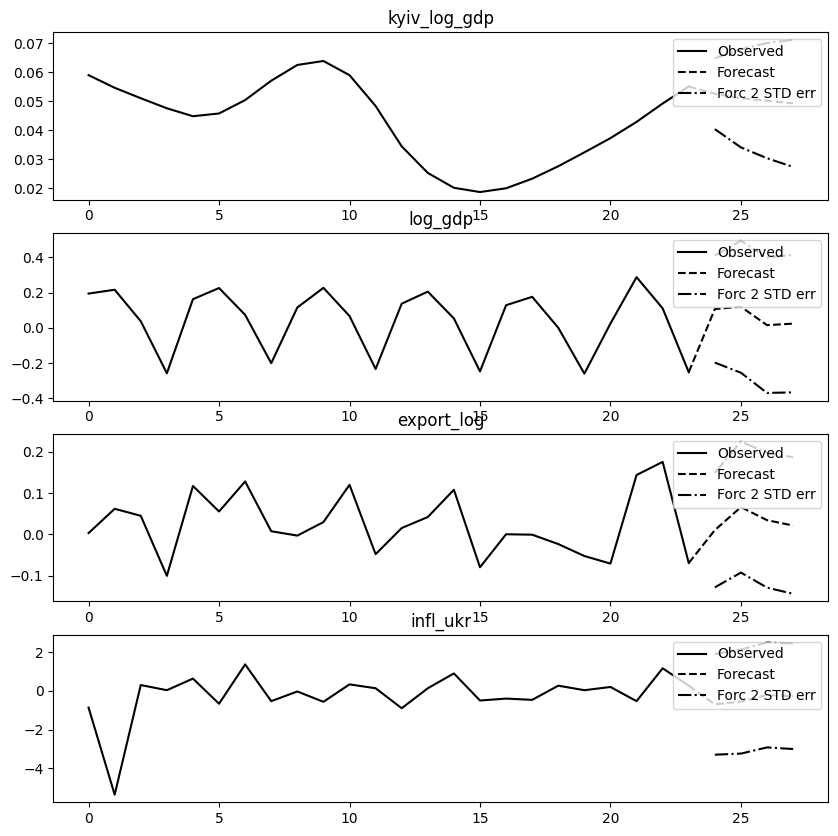

In [197]:
results = model.fit(1)
print(results.summary())

# Прогноз на наступні 4 квартали (1 рік)
lag_order = results.k_ar
forecast = results.forecast(data_diff.values[-lag_order:], steps=4)

# Візуалізація результатів для однієї зі змінних
results.plot_forecast(4)
plt.show()

In [202]:
import numpy as np


# Перетворюємо масив прогнозу назад у DataFrame для зручності
forecast_df = pd.DataFrame(forecast, columns=data_diff.columns)

# 2. Відновлюємо ЛОГАРИФМИ (додаємо прогнозовані зміни до останнього відомого логарифму)
# Беремо останні значення логарифмів з робочого датасету (data) перед diff()
last_log_values = data[['kyiv_log_gdp', 'log_gdp', 'export_log', 'infl_ukr']].iloc[-1]

# Робимо кумулятивну суму змін
forecast_logs = forecast_df.cumsum() + last_log_values.values

# 3. Відновлюємо РЕАЛЬНІ ЗНАЧЕННЯ (експонента)
forecast_real = np.exp(forecast_logs[['log_gdp', 'kyiv_log_gdp', 'export_log']])

# Інфляцію просто повертаємо (якщо вона не логарифмувалася, а тільки диференціювалася)
forecast_real['infl_ukr'] = forecast_logs['infl_ukr'] # або інша логіка залежно від твоїх змінних

forecast_real = pd.DataFrame(forecast_real)
print("Прогноз ВВП (в оригінальних одиницях):")
print(forecast_real)

Прогноз ВВП (в оригінальних одиницях):
        log_gdp   kyiv_log_gdp     export_log    infl_ukr
0  1.134502e+06  307266.808151  461695.682001  100.633423
1  1.278905e+06  323348.468692  493140.942007  100.079012
2  1.298966e+06  339999.103723  510333.906519   99.866943
3  1.330582e+06  357167.472969  521333.814243   99.586216


In [203]:
forecast_real['log_gdp']

0    1.134502e+06
1    1.278905e+06
2    1.298966e+06
3    1.330582e+06
Name: log_gdp, dtype: float64

In [204]:
print(forecast_real.round(2))

      log_gdp  kyiv_log_gdp  export_log  infl_ukr
0  1134502.49     307266.81   461695.68    100.63
1  1278904.66     323348.47   493140.94    100.08
2  1298966.28     339999.10   510333.91     99.87
3  1330582.46     357167.47   521333.81     99.59
